In [1]:
# Import Libraries and necessary functions for the tasks at hand
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


### Task 1 - Understanding the data

In [27]:
# Importing the dataset
df = pd.read_csv("PGR304 final_selected_load_predictors.csv", parse_dates=["timestamp"], index_col="timestamp")

df.head()

,load_MW,temp_C,price_DA_EUR_MWh,solar_MW,clouds_pct
timestamp,,,,,
2014-12-31 23:00:00+00:00,25385.0,-2.675,50.10,49.0,0
2015-01-01 00:00:00+00:00,24382.0,-2.675,48.10,50.0,0
2015-01-01 01:00:00+00:00,22734.0,-3.464,47.33,50.0,0
2015-01-01 02:00:00+00:00,21286.0,-3.464,42.27,50.0,0
2015-01-01 03:00:00+00:00,20264.0,-3.464,38.41,42.0,0


In [28]:
# Getting some statistics from the dataset
df.describe()

,load_MW,temp_C,price_DA_EUR_MWh,solar_MW,clouds_pct
count,35028.000000,35064.000000,35064.000000,35046.000000,35064.000000
mean,28696.939905,17.633954,49.874341,1432.665925,20.740475
std,4574.987950,7.234569,14.618900,1680.119887,25.604016
min,18041.000000,-4.319344,2.060000,0.000000,0.000000
25%,24807.750000,12.000000,41.490000,71.000000,0.000000
50%,28901.000000,17.040000,50.520000,616.000000,20.000000
75%,32192.000000,23.000000,60.530000,2578.000000,20.000000
max,41015.000000,38.000000,101.990000,5792.000000,100.000000


In [29]:
# NaN values per column
nan_counts = df.isna().sum()

# Blank (empty string) values per column
blank_counts = (df == '').sum()

# Combine both
missing_counts = nan_counts + blank_counts

print("NaN counts per column:\n", nan_counts)
print("\nBlank counts per column:\n", blank_counts)
print("\nTotal missing (NaN + blank) per column:\n", missing_counts)

NaN counts per column:
 load_MW             36
temp_C               0
price_DA_EUR_MWh     0
solar_MW            18
clouds_pct           0
dtype: int64

Blank counts per column:
 load_MW             0
temp_C              0
price_DA_EUR_MWh    0
solar_MW            0
clouds_pct          0
dtype: int64

Total missing (NaN + blank) per column:
 load_MW             36
temp_C               0
price_DA_EUR_MWh     0
solar_MW            18
clouds_pct           0
dtype: int64


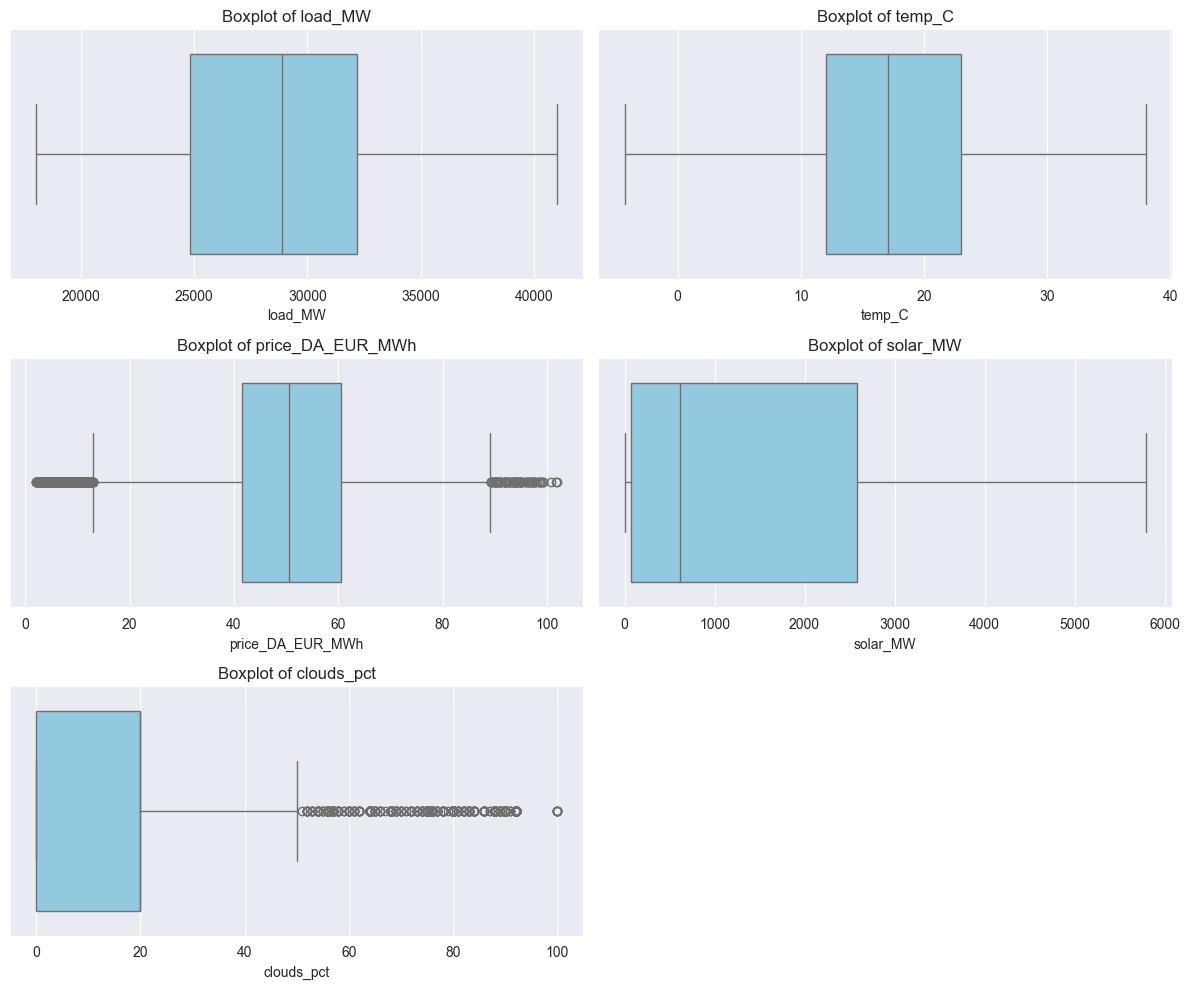

In [30]:
# Making boxplots

variables = ['load_MW', 'temp_C', 'price_DA_EUR_MWh', 'solar_MW', 'clouds_pct']

plt.figure(figsize=(12, 10))

for i, var in enumerate(variables, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df[var], color="skyblue")
    plt.title(f'Boxplot of {var}')
    plt.tight_layout()

plt.show()


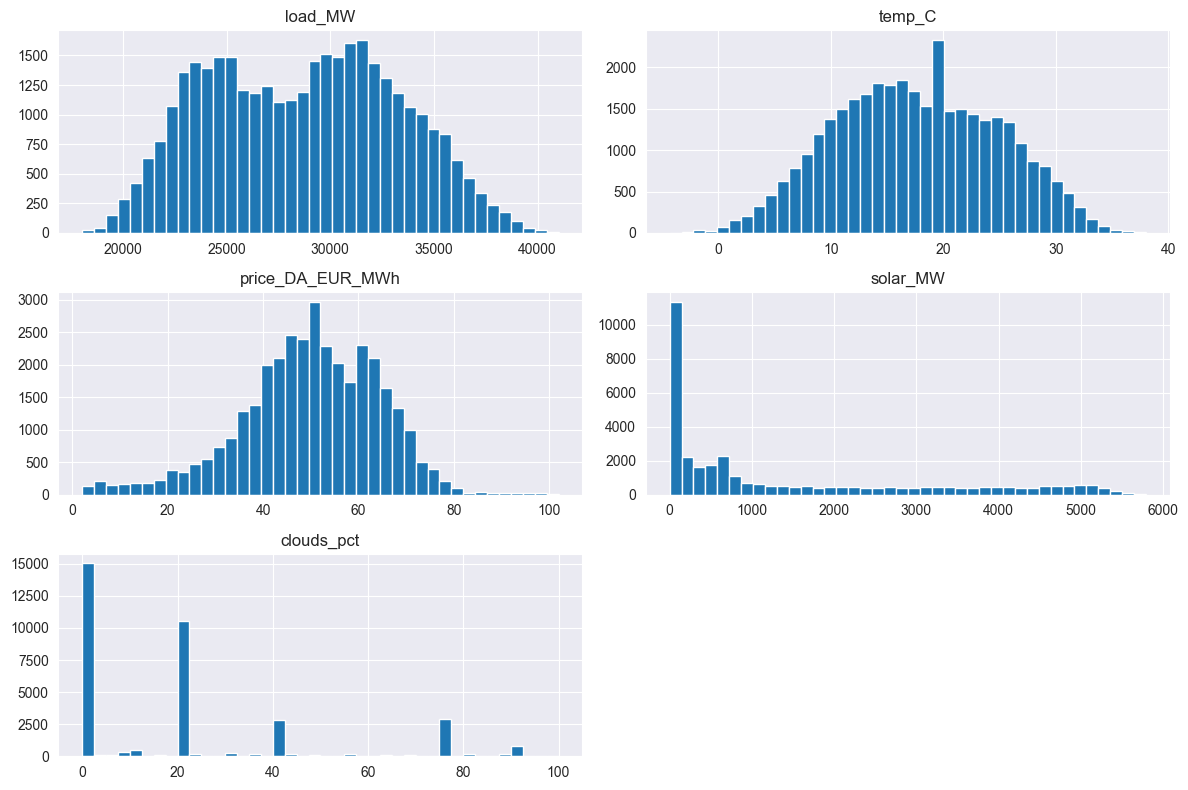

In [31]:
# Histogram

df.hist(figsize=(12,8), bins=40)
plt.tight_layout()
plt.show()


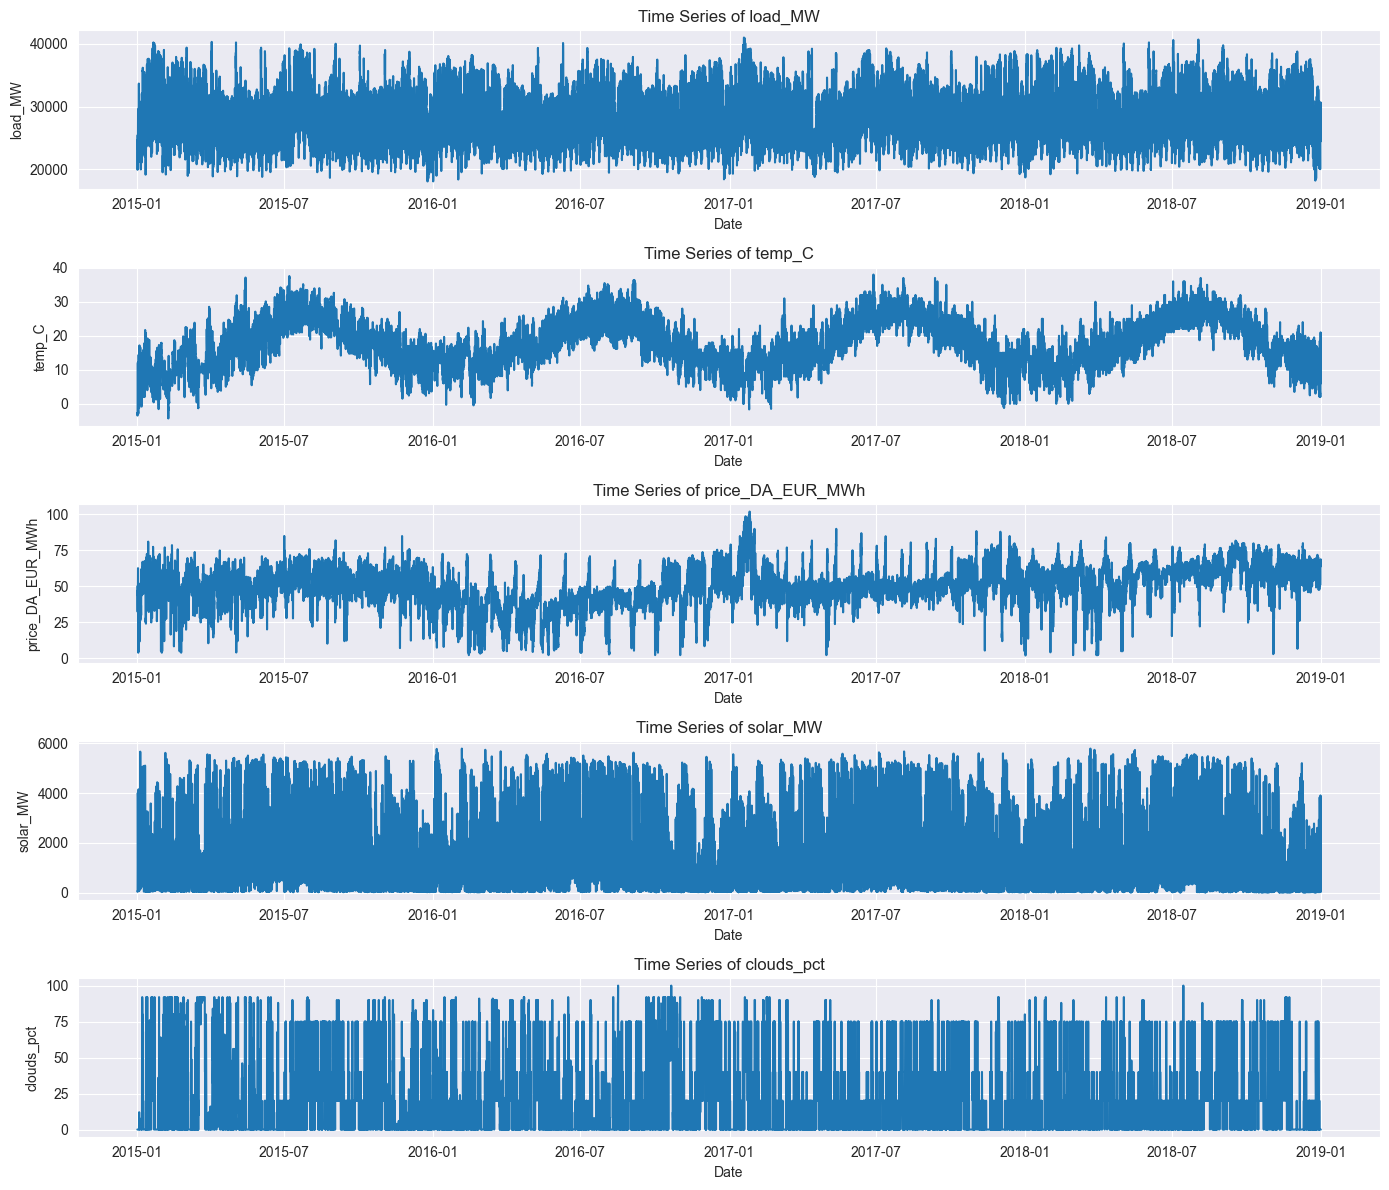

In [32]:
# Time series of the different variables

variables = ['load_MW', 'temp_C', 'price_DA_EUR_MWh', 'solar_MW', 'clouds_pct']

plt.figure(figsize=(14, 12))

for i, var in enumerate(variables, 1):
    plt.subplot(5, 1, i)
    plt.plot(df.index, df[var])
    plt.title(f'Time Series of {var}')
    plt.xlabel('Date')
    plt.ylabel(var)
    plt.tight_layout()

plt.show()

### Task 2 - Utility Value

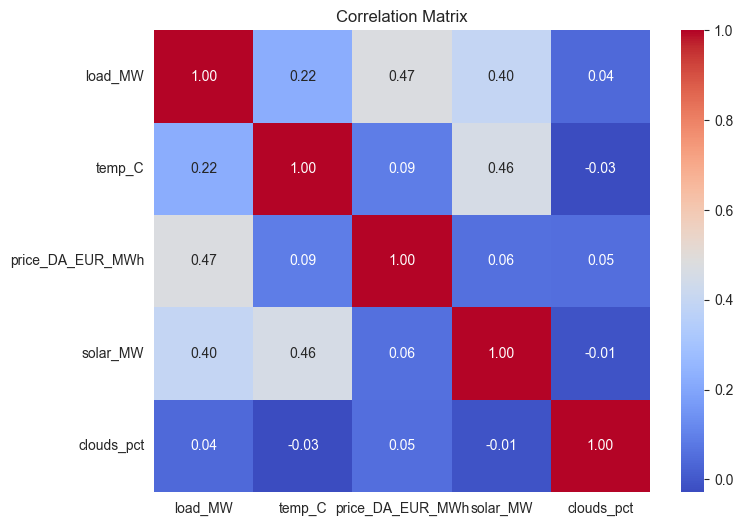

In [33]:
# Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [34]:
# Prepare dataset for VAR
df_var = df[['load_MW', 'temp_C', 'price_DA_EUR_MWh', 'solar_MW', 'clouds_pct']].copy()
df_var = df_var.dropna() # Dropped missing rows


In [35]:
# Fit a VAR model and printing summary
model = VAR(df_var)
results = model.fit(1)
print(results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 18, Nov, 2025
Time:                     01:38:33
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    34.4046
Nobs:                     35022.0    HQIC:                   34.3996
Log likelihood:          -850772.    FPE:                8.68097e+14
AIC:                      34.3973    Det(Omega_mle):     8.67354e+14
--------------------------------------------------------------------
Results for equation load_MW
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                    1648.188159        52.044104           31.669           0.000
L1.load_MW                  0.944031         0.002059          458.471           0.000
L1.temp_C                 -17.6331

C:\Users\ranie\pythonProject\AdvanceProgramming\PGR304Exam\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [36]:
# Stationary Test using ADF and KPSS

# ADF Test
def adf_test(series):
    result = adfuller(series.dropna(), autolag='AIC')
    return result[0], result[1] 

#KPSS Test
def kpss_test(series):
    result = kpss(series.dropna(), nlags="auto")
    return result[0], result[1]

variables = ['load_MW', 'temp_C', 'price_DA_EUR_MWh', 'solar_MW', 'clouds_pct']

rows = []

# Run ADF and KPSS tests for each variable
for var in variables:
    adf_stat, adf_p = adf_test(df[var])
    kpss_stat, kpss_p = kpss_test(df[var])
    
    rows.append({
        "Variable": var,
        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p
    })

# Create results table
stationarity_table = pd.DataFrame(rows)
stationarity_table


C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), nlags="auto")
C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), nlags="auto")
C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), nlags="auto")
C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available

,Variable,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value
0,load_MW,-21.469873,0.000000e+00,0.873417,0.01
1,temp_C,-5.548531,1.639789e-06,1.124922,0.01
2,price_DA_EUR_MWh,-12.288647,7.919258e-23,6.940152,0.01
3,solar_MW,-13.861546,6.714938e-26,0.861583,0.01
4,clouds_pct,-17.819525,3.165186e-30,0.312076,0.10


In [37]:
# Apply first-order differencing to all selected variable
df_diff = df[variables].diff()

rows_diff = []

# Perform ADF and KPSS tests on each differenced variable and collect result
for var in variables:
    adf_stat, adf_p = adf_test(df_diff[var])
    kpss_stat, kpss_p = kpss_test(df_diff[var])
    
    rows_diff.append({
        "Variable": var + "_diff",
        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p
    })

# Convert results into a DataFrame for easy viewing
stationarity_table_diff = pd.DataFrame(rows_diff)
stationarity_table_diff


C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), nlags="auto")
C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), nlags="auto")
C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), nlags="auto")
C:\Users\ranie\AppData\Local\Temp\ipykernel_48944\2262987770.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available

,Variable,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value
0,load_MW_diff,-34.082107,0.0,0.050607,0.1
1,temp_C_diff,-32.864223,0.0,0.095123,0.1
2,price_DA_EUR_MWh_diff,-32.317236,0.0,0.014317,0.1
3,solar_MW_diff,-35.364490,0.0,0.005489,0.1
4,clouds_pct_diff,-38.663936,0.0,0.005174,0.1


In [38]:
# First-order differencing to enforce stationarity

# Create differenced versions of all variables.
df['load_MW_diff'] = df['load_MW'].diff()
df['temp_C_diff'] = df['temp_C'].diff()
df['price_DA_EUR_MWh_diff'] = df['price_DA_EUR_MWh'].diff()
df['solar_MW_diff'] = df['solar_MW'].diff()
df['clouds_pct_diff'] = df['clouds_pct'].diff()

# Select only the differenced columns and drop the first NaN row created by .diff()
df_diff = df[['load_MW_diff','temp_C_diff','price_DA_EUR_MWh_diff','solar_MW_diff','clouds_pct_diff']].dropna()

# Quick preview of differenced dataset
df_diff.head()


,load_MW_diff,temp_C_diff,price_DA_EUR_MWh_diff,solar_MW_diff,clouds_pct_diff
timestamp,,,,,
2015-01-01 00:00:00+00:00,-1003.0,0.000,-2.00,1.0,0.0
2015-01-01 01:00:00+00:00,-1648.0,-0.789,-0.77,0.0,0.0
2015-01-01 02:00:00+00:00,-1448.0,0.000,-5.06,0.0,0.0
2015-01-01 03:00:00+00:00,-1022.0,0.000,-3.86,-8.0,0.0
2015-01-01 04:00:00+00:00,-359.0,0.606,-2.69,-8.0,0.0


### Task 3 - Analysis, modeling and prediction

In [47]:
# Ensure index is datetime
df.index = pd.to_datetime(df.index)
df_diff.index = pd.to_datetime(df_diff.index)

# Sort by time
df = df.sort_index()
df_diff = df_diff.sort_index()

# Define test set (last 48 hours)
test_horizon = 48
df_test = df.iloc[-test_horizon:]          # last 48 hours
df_train_full = df.iloc[:-test_horizon]    # everything before the test set

# Use the last 365 days of data for training
end_date = df_train_full.index.max()
start_date = end_date - pd.Timedelta(days=365)
df_train_1y = df_train_full.loc[start_date:end_date]

# Align differenced data with the same train/test split
train_index = df_train_1y.index.intersection(df_diff.index)
diff_train = df_diff.loc[train_index]

test_index = df_test.index.intersection(df_diff.index)
diff_test = df_diff.loc[test_index]

In [50]:
print("\n*** Train/Test Split ***")

print(f"Train (levels): {df_train_1y.index.min()}  →  {df_train_1y.index.max()}  |  n={len(df_train_1y)}")
print(f"Train (diff)  : {diff_train.index.min()}  →  {diff_train.index.max()}  |  n={len(diff_train)}\n")

print(f"Test (levels):  {df_test.index.min()}  →  {df_test.index.max()}  |  n={len(df_test)}")
print(f"Test (diff)  :  {diff_test.index.min()}  →  {diff_test.index.max()}  |  n={len(diff_test)}")

print("\nAligned?  Train:", diff_train.index.isin(df_train_1y.index).all(),
      " | Test:", diff_test.index.isin(df_test.index).all())



*** Train/Test Split ***
Train (levels): 2017-12-29 22:00:00+00:00  →  2018-12-29 22:00:00+00:00  |  n=8761
Train (diff)  : 2017-12-29 22:00:00+00:00  →  2018-12-29 22:00:00+00:00  |  n=8757

Test (levels):  2018-12-29 23:00:00+00:00  →  2018-12-31 22:00:00+00:00  |  n=48
Test (diff)  :  2018-12-29 23:00:00+00:00  →  2018-12-31 22:00:00+00:00  |  n=48

Aligned?  Train: True  | Test: True


### VAR

In [70]:
# Fit VAR and select lag order by AIC
var_model = VAR(diff_train)

lag_order_results = var_model.select_order(maxlags=24)
print("VAR lag order selection:")
print(lag_order_results.summary())

# Choose lag with lowest AIC
p = lag_order_results.aic
print("\nSelected VAR lag order (AIC):", p)

C:\Users\ranie\pythonProject\AdvanceProgramming\PGR304Exam\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


VAR lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        34.41       34.41   8.800e+14       34.41
1        32.27       32.29   1.033e+14       32.28
2        31.90       31.94   7.122e+13       31.91
3        31.80       31.86   6.441e+13       31.82
4        31.70       31.79   5.876e+13       31.73
5        31.59       31.69   5.218e+13       31.62
6        31.49       31.62   4.743e+13       31.53
7        31.39       31.54   4.311e+13       31.44
8        31.33       31.50   4.044e+13       31.39
9        31.30       31.48   3.903e+13       31.36
10       31.22       31.42   3.610e+13       31.29
11       31.15       31.38   3.389e+13       31.23
12       31.06       31.30   3.078e+13       31.14
13       31.01       31.28   2.944e+13       31.10
14       30.98       31.27   2.861e+13       31.08
15       30.95       31.25   2.752e+13       31.05
16    

In [67]:
# Check which lag order was selected
print("Selected VAR lag order (p):", var_res.k_ar)

# Coefficient matrices for all lags
all_lags = var_res.coefs
print("Coefs shape (lags, variables, variables):", all_lags.shape)

# Lag 1 coefficient matrix (most important short-term effect)
lag1_df = pd.DataFrame(
    all_lags[0],                      # 0 = lag 1
    columns=diff_train.columns,       # lagged variables (t-1)
    index=diff_train.columns          # predicted variables (t)
)

print("\nLag 1 coefficient matrix:")
display(lag1_df)

# Effects of lag-1 predictors on load_MW_diff
print("\nLag 1 influence on load_MW_diff:")
display(lag1_df.loc['load_MW_diff'].sort_values(ascending=False))

# Strongest absolute influence across ALL lags for load_MW_diff
max_abs = np.max(np.abs(all_lags[:, diff_train.columns.get_loc('load_MW_diff'), :]), axis=0)
max_abs_df = pd.Series(max_abs, index=diff_train.columns).sort_values(ascending=False)

print("\nMaximum absolute influence on load_MW_diff across ALL lags:")
display(max_abs_df)


Selected VAR lag order (p): 24
Coefs shape (lags, variables, variables): (24, 5, 5)

Lag 1 coefficient matrix:


,load_MW_diff,temp_C_diff,price_DA_EUR_MWh_diff,solar_MW_diff,clouds_pct_diff
load_MW_diff,0.354176,5.479529,20.849434,-0.747148,-1.269761
temp_C_diff,-0.000011,-0.070216,0.000838,0.000438,-0.001308
price_DA_EUR_MWh_diff,0.000394,0.033731,0.089435,-0.001810,0.002508
solar_MW_diff,-0.014708,-5.990159,0.513345,0.681484,-0.175768
clouds_pct_diff,-0.000084,0.207036,0.006865,0.001576,-0.238300



Lag 1 influence on load_MW_diff:


price_DA_EUR_MWh_diff    20.849434
temp_C_diff               5.479529
load_MW_diff              0.354176
solar_MW_diff            -0.747148
clouds_pct_diff          -1.269761
Name: load_MW_diff, dtype: float64


Maximum absolute influence on load_MW_diff across ALL lags:


temp_C_diff              43.318967
price_DA_EUR_MWh_diff    20.849434
clouds_pct_diff           1.755485
solar_MW_diff             0.747148
load_MW_diff              0.354176
dtype: float64

In [60]:
var_res = var_model.fit(p)
print(var_res.summary())

# Forecast differenced values for the next 48 steps
test_horizon = len(df_test)  # should be 48
var_forecast_diff = var_res.forecast(diff_train.values[-p:], steps=test_horizon)

var_forecast_diff_df = pd.DataFrame(
    var_forecast_diff,
    index=df_test.index,              # align with test timestamps
    columns=diff_train.columns
)

var_forecast_diff_df.head()


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 18, Nov, 2025
Time:                     02:13:07
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    30.8536
Nobs:                     8733.00    HQIC:                   30.5305
Log likelihood:          -193935.    FPE:                1.53711e+13
AIC:                      30.3635    Det(Omega_mle):     1.43491e+13
--------------------------------------------------------------------
Results for equation load_MW_diff
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                            -0.801371         7.246166           -0.111           0.912
L1.load_MW_diff                   0.354176         0.011298           31.348           0.000
L1.te

,load_MW_diff,temp_C_diff,price_DA_EUR_MWh_diff,solar_MW_diff,clouds_pct_diff
timestamp,,,,,
2018-12-29 23:00:00+00:00,-2077.991746,-0.282458,-2.647728,14.093810,-0.597598
2018-12-30 00:00:00+00:00,-2160.025059,-0.173850,-3.839616,2.838572,-2.162357
2018-12-30 01:00:00+00:00,-1668.711963,0.007778,-3.040610,-10.976847,-3.385069
2018-12-30 02:00:00+00:00,-715.287802,-0.101986,-1.132918,-35.069765,-1.290856
2018-12-30 03:00:00+00:00,-59.726308,-0.408599,-0.065617,-91.001829,1.042064


VAR MODEL PERFORMANCE (load_MW, 48h test)
MSE  : 2366906.32
RMSE : 1538.48
MAE  : 1195.08
MAPE : 4.83%


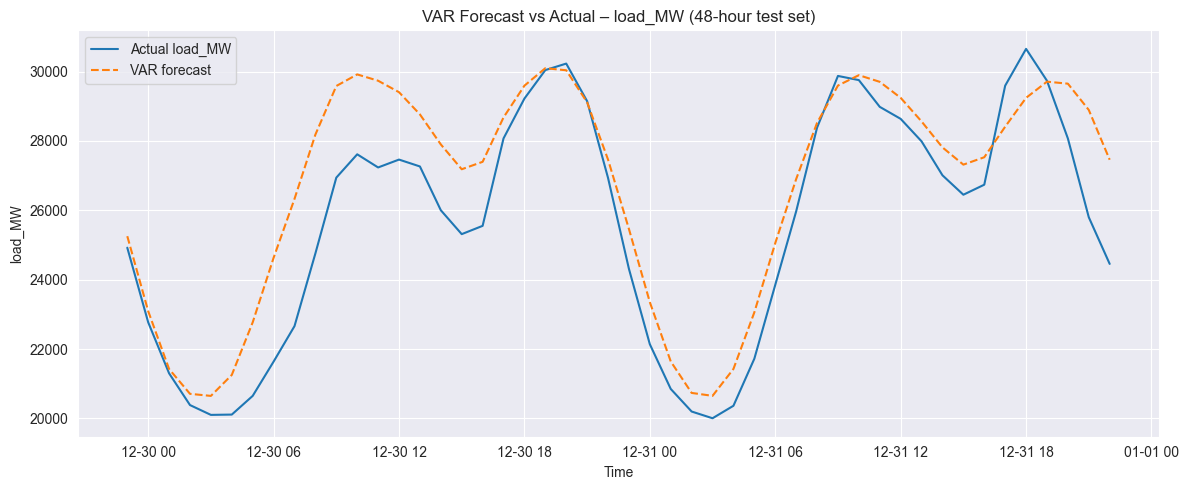

In [59]:
# VAR – back-transform, metrics and plot
# Back-transform from differenced load_MW to original MW scale

# Last observed load_MW value before the test window
last_train_level = df_train_full['load_MW'].iloc[-1]

var_load_pred_levels = []
last_level = last_train_level

for t in df_test.index:
    diff_pred = var_forecast_diff_df.loc[t, 'load_MW_diff']  # predicted difference
    level_pred = last_level + diff_pred
    var_load_pred_levels.append(level_pred)
    last_level = level_pred

# VAR forecast in original scale
var_load_pred = pd.Series(
    var_load_pred_levels,
    index=df_test.index,
    name='load_MW_VAR_pred'
)

# Evaluation: MSE, RMSE, MAE, MAPE

y_true = df_test['load_MW']
y_pred_var = var_load_pred

mse_var = mean_squared_error(y_true, y_pred_var)
rmse_var = np.sqrt(mse_var)
mae_var = mean_absolute_error(y_true, y_pred_var)
mape_var = np.mean(np.abs((y_true - y_pred_var) / y_true)) * 100

print("VAR MODEL PERFORMANCE (load_MW, 48h test)")
print(f"MSE  : {mse_var:.2f}")
print(f"RMSE : {rmse_var:.2f}")
print(f"MAE  : {mae_var:.2f}")
print(f"MAPE : {mape_var:.2f}%")

# Plot Actual vs Forecast

plt.figure(figsize=(12, 5))
plt.plot(y_true, label='Actual load_MW')
plt.plot(y_pred_var, label='VAR forecast', linestyle='--')
plt.title('VAR Forecast vs Actual – load_MW (48-hour test set)')
plt.xlabel('Time')
plt.ylabel('load_MW')
plt.legend()
plt.tight_layout()
plt.show()



In [44]:
# Use the same train/test split as VAR, but only for load_MW
load_train = df_train_1y['load_MW']
load_test = df_test['load_MW']

print("Train length:", len(load_train))
print("Test length :", len(load_test))

# Grid search over ARIMA(p,1,q) with small p,q ranges
best_aic = np.inf
best_order = None
best_model = None

for p in range(0, 4):      # p = 0,1,2,3
    for q in range(0, 4):  # q = 0,1,2,3
        order = (p, 1, q)
        try:
            model = ARIMA(load_train, order=order)
            res = model.fit()
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = order
                best_model = res
        except Exception as e:
            continue

print("\nBest ARIMA order (by AIC):", best_order, "with AIC =", best_aic)


Train length: 8761
Test length : 48


C:\Users\ranie\pythonProject\AdvanceProgramming\PGR304Exam\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\ranie\pythonProject\AdvanceProgramming\PGR304Exam\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\ranie\pythonProject\AdvanceProgramming\PGR304Exam\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\ranie\pythonProject\AdvanceProgramming\PGR304Exam\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\ranie\pythonProject\AdvanceProgramm


Best ARIMA order (by AIC): (3, 1, 3) with AIC = 144588.8229632399


### ARIMA

ARIMA MODEL PERFORMANCE (load_MW, 48h test)
Order: (3, 1, 3)
MSE  : 10569695.13
RMSE : 3251.11
MAE  : 2597.43
MAPE : 11.19%


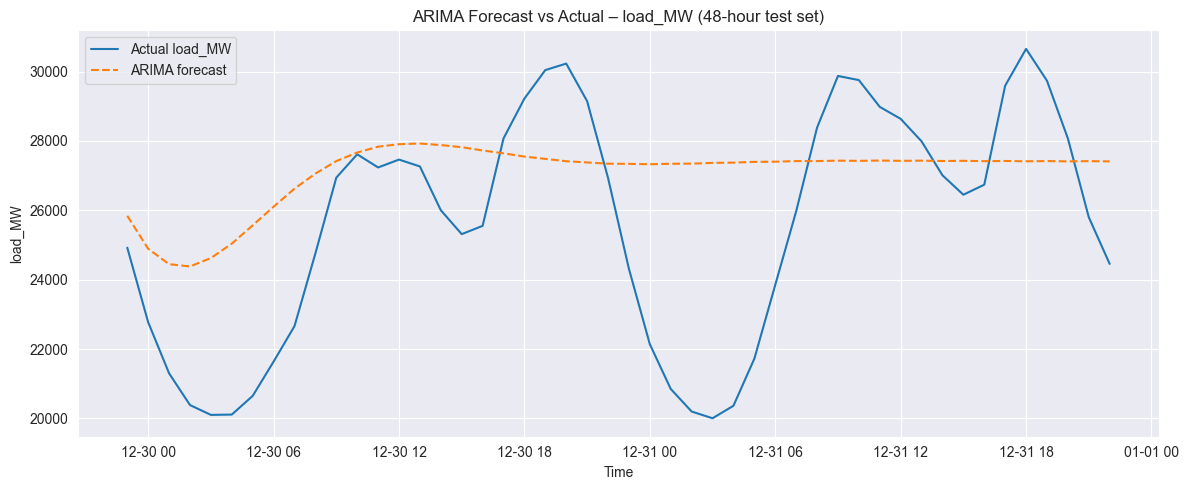

In [61]:
# Forecast 48 hours ahead using the best ARIMA model
test_horizon = len(load_test)  # should be 48
arima_forecast = best_model.forecast(steps=test_horizon)

arima_pred = pd.Series(
    arima_forecast,
    index=load_test.index,
    name='load_MW_ARIMA_pred'
)

# Evaluation for ARIMA
y_true = load_test
y_pred_arima = arima_pred

mse_arima = mean_squared_error(y_true, y_pred_arima)
rmse_arima = np.sqrt(mse_arima)
mae_arima = mean_absolute_error(y_true, y_pred_arima)
mape_arima = np.mean(np.abs((y_true - y_pred_arima) / y_true)) * 100

print("ARIMA MODEL PERFORMANCE (load_MW, 48h test)")
print(f"Order: {best_order}")
print(f"MSE  : {mse_arima:.2f}")
print(f"RMSE : {rmse_arima:.2f}")
print(f"MAE  : {mae_arima:.2f}")
print(f"MAPE : {mape_arima:.2f}%")

# Plot ARIMA forecast vs actual
plt.figure(figsize=(12, 5))
plt.plot(y_true, label='Actual load_MW')
plt.plot(y_pred_arima, label='ARIMA forecast', linestyle='--')
plt.title('ARIMA Forecast vs Actual – load_MW (48-hour test set)')
plt.xlabel('Time')
plt.ylabel('load_MW')
plt.legend()
plt.tight_layout()
plt.show()

### Comparing VAR and ARIMA results


COMPARISON: VAR vs ARIMA (load_MW, 48h test)
VAR   - MAE: 1195.08,  RMSE: 1538.48,  MAPE: 4.83%
ARIMA - MAE: 2597.43, RMSE: 3251.11, MAPE: 11.19%


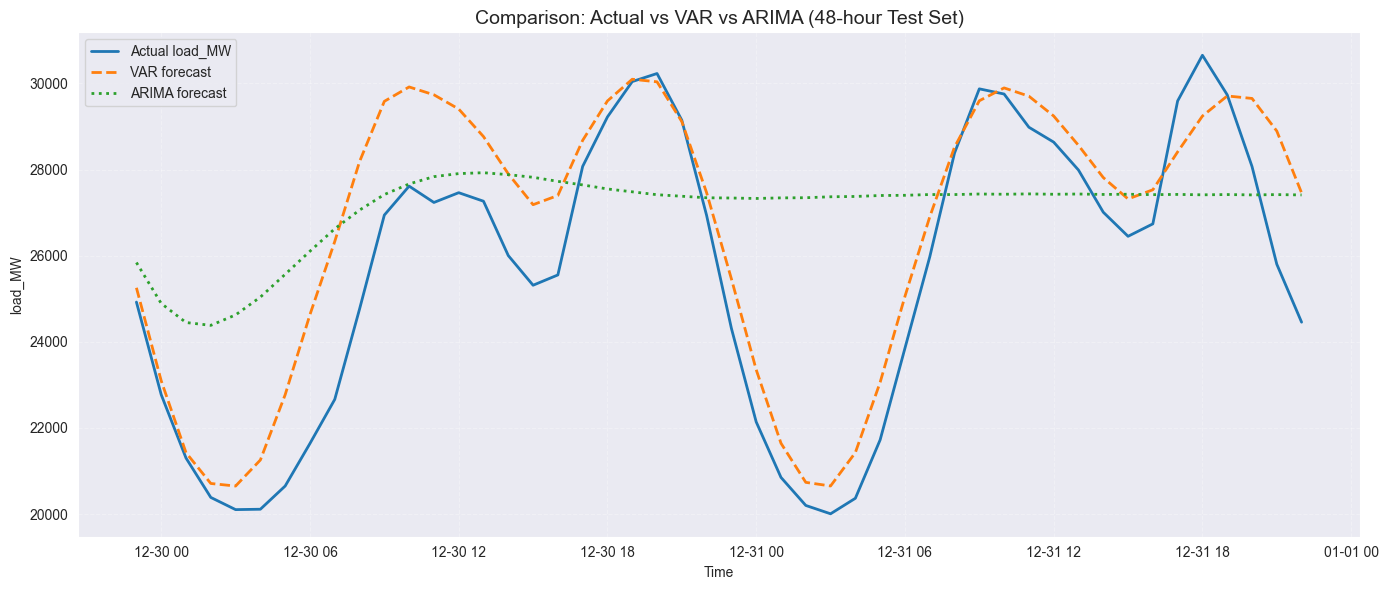

In [62]:
# Side-by-side comparison VAR vs ARIMA (uses metrics from your VAR cell)
print("\nCOMPARISON: VAR vs ARIMA (load_MW, 48h test)")
print(f"VAR   - MAE: {mae_var:.2f},  RMSE: {rmse_var:.2f},  MAPE: {mape_var:.2f}%")
print(f"ARIMA - MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}%")

# Visual comparison between the two models
plt.figure(figsize=(14, 6))

# Plot actual
plt.plot(df_test.index, df_test["load_MW"], label="Actual load_MW",
         linewidth=2)

# Plot VAR forecast
plt.plot(df_test.index, y_pred_var, label="VAR forecast",
         linestyle="--", linewidth=2)

# Plot ARIMA forecast
plt.plot(df_test.index, y_pred_arima, label="ARIMA forecast",
         linestyle=":", linewidth=2)

plt.title("Comparison: Actual vs VAR vs ARIMA (48-hour Test Set)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("load_MW")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
